# Finding Space-Time Clusters in San Diego 311 Encampment Reports

The ability to take a messy public dataset and turn it into something a statistical model will actually accept is a generally useful skill that transfers well beyond spatial epidemiology. In this tutorial, I analyze publicly available 311 service request data from the City of San Diego, hosted on the [Homelessness Hub San Diego](https://hhubsandiego-ucsdonline.hub.arcgis.com/) ArcGIS portal maintained by UC San Diego.

The dataset comprises every 311 encampment report filed in the city — when someone called or used the app, roughly where they said the encampment was, and what happened to the request. Our goal is to reshape this into the two input files that [SaTScan](https://www.satscan.org/) needs so we can ask a specific question: **were there particular places and particular stretches of time in 2024 where encampment reports clustered more than we would expect by chance?**

Let's download the data and take a look for ourselves in Python.

---

## Getting started: download and read in data

I downloaded the data from the [311 Encampment Reports dataset page](https://hhubsandiego-ucsdonline.hub.arcgis.com/datasets/9d27b009ddec489b982481e38f7c9c80_0/explore). Click **Download** and choose the CSV option. The file I use here is named `311_Encampment_Reports_2C_2024_2C_City_of_San_Diego.csv`.

Unlike a lot of public data, this one is refreshingly well-behaved: one row per report, one file, real column headers on line one. There are a few quirks we'll hit later, but no hunting for which sheet the data is on.

A note on scope: I focus on 2024 because it is the most recent complete calendar year. If you pull a different year, or the multi-year version of this dataset, everything below still works — but pay attention to the study period at the very end, since a partial year will quietly distort the temporal baseline SaTScan compares against.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "311_Encampment_Reports%2C_2024%2C_City_of_San_Diego.csv"
df = pd.read_csv(CSV_PATH)

print(df.shape)
df.head()

(59059, 26)


,x,y,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,...,council_district,comm_plan_code,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description,ObjectId
0,-117.154526,32.716936,4563179,NaN,NaN,2024/01/01 08:32:00+00,1,Neighborhood Policing,Encampment,NaN,...,3.0,4.0,Downtown,NaN,Mobile,NaN,SS-005228,SS-005228,Homeless encampment,1
1,-117.131777,32.748568,4563180,NaN,NaN,2024/01/01 08:36:00+00,10,Neighborhood Policing,Encampment,NaN,...,3.0,28.0,North Park,NaN,Mobile,NaN,SS-027156,SS-027156,homeless encampment overnight on university av...,2
2,-117.116820,32.916662,4563181,4562634.0,NaN,2024/01/01 08:38:00+00,2,ESD Complaint/Report,Encampment,NaN,...,6.0,15.0,Mira Mesa,NaN,Web,NaN,NaN,NaN,Lots and lots of shopping carts and belongings...,3
3,-117.158849,32.713853,4563187,4559798.0,NaN,2024/01/01 09:14:00+00,4,Neighborhood Policing,Encampment,NaN,...,3.0,4.0,Downtown,NaN,Mobile,NaN,SS-010715,SS-010715,Homeless Andaz,4
4,-117.148147,32.705174,4563192,NaN,NaN,2024/01/01 11:23:00+00,1,Neighborhood Policing,Encampment,NaN,...,8.0,2.0,Barrio Logan,NaN,Mobile,NaN,SS-007733,SS-007733,Camping in a no camping zone,5


59,059 rows and 26 columns. Note each row is a single 311 report — not a single encampment, and not a single person. This distinction matters more than almost anything else in this tutorial, and we will return to it.

Let's see what we're given.

In [4]:
df.dtypes

x                            float64
y                            float64
service_request_id             int64
service_request_parent_id    float64
sap_notification_number      float64
date_requested                object
case_age_days                  int64
case_record_type              object
service_name                  object
service_name_detail          float64
date_closed                   object
status                        object
lat                          float64
lng                          float64
street_address                object
zipcode                      float64
council_district             float64
comm_plan_code               float64
comm_plan_name                object
park_name                     object
case_origin                   object
referred                      object
iamfloc                       object
floc                          object
public_description            object
ObjectId                       int64
dtype: object

Most of these we won't need. For cluster detection, only three things matter:

| What SaTScan needs | Column here |
|---|---|
| **When** did it happen | `date_requested` |
| **Where** did it happen | `lat`, `lng` |
| **How many** happened there, then | we compute this by counting |

Everything else — `council_district`, `comm_plan_name`, `status`, `case_age_days` — is useful for exploration and for interpreting results afterward, but it isn't part of the model input.

Before we throw the extra columns away, though, let's use them.

## What does this data actually contain?

It is tempting to jump straight to modeling. Resist. Nearly every mistake in spatial analysis is a mistake about what the data *is*, and those are much easier to catch with a plot than with a p-value.

First, a sanity check on the filter.

In [5]:
print(df["service_name"].value_counts())
print()
print(df["status"].value_counts())

Encampment    59059
Name: service_name, dtype: int64

Closed      53133
Referred     5926
Name: status, dtype: int64


Every row is already an `Encampment` report, so this particular export needs no subsetting. We will still write the filter explicitly below — partly so the code documents its own assumption, and partly because if you re-download this dataset next year and the city has folded in a second service type, a silent change is much worse than a loud one.

Now, when did these reports come in?

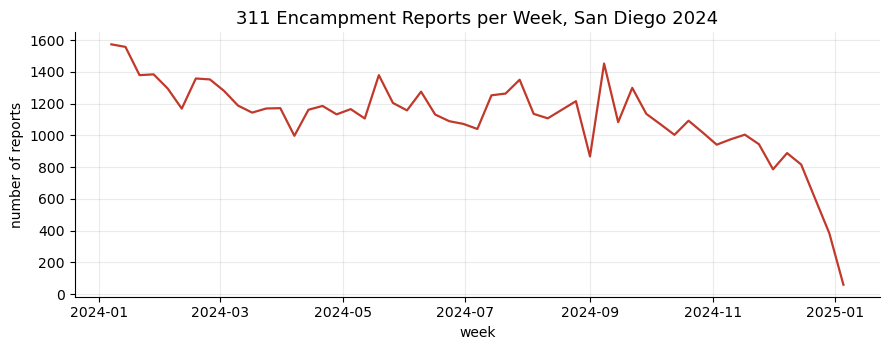

In [6]:
dates = pd.to_datetime(df["date_requested"], utc=True).dt.date
weekly = pd.Series(1, index=pd.to_datetime(dates)).resample("W").sum()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(weekly.index, weekly.values, color="#c0392b", lw=1.6)
ax.set_title("311 Encampment Reports per Week, San Diego 2024", fontsize=13)
ax.set_xlabel("week")
ax.set_ylabel("number of reports")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Reports range from about 60 to about 1,570 per week. That is a *twenty-six-fold* swing within a single year, and it is worth sitting with for a moment.

Does that mean the number of encampments swung twenty-six-fold? Almost certainly not. Report volume responds to enforcement pushes, media coverage, weather, and whether the city ran an outreach campaign that month. What we are measuring is **reporting behavior**, which is related to the underlying phenomenon but is emphatically not the same variable.

This is the single most important caveat in the entire tutorial, so let me state it plainly: **SaTScan will find clusters in whatever you feed it.** If you feed it reports, it finds clusters of *reporting*. Whether those correspond to clusters of encampments is a question the statistics cannot answer for you.

Where are the reports coming from?

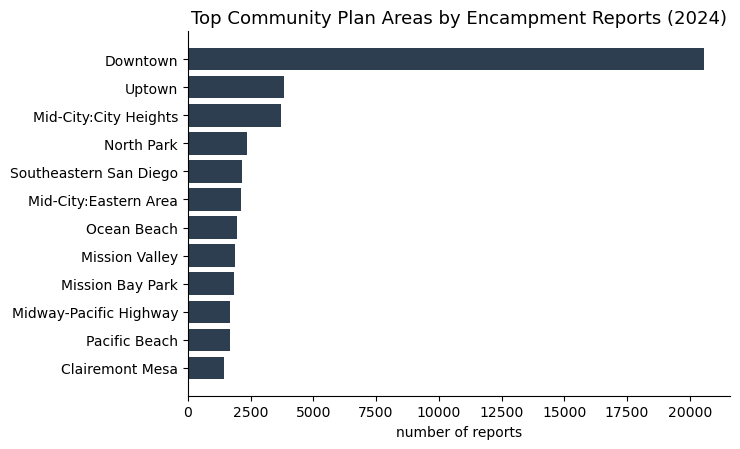

In [7]:
# Note: comm_plan_name has inconsistent casing ('Downtown' vs 'DOWNTOWN'),
# a classic public-data quirk. .str.title() folds them together.
cp = df["comm_plan_name"].str.title().value_counts().head(12).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.barh(cp.index, cp.values, color="#2c3e50")
ax.set_title("Top Community Plan Areas by Encampment Reports (2024)", fontsize=13)
ax.set_xlabel("number of reports")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Had we not folded the casing, Downtown would have been split into two bars and neither would have topped the chart. Small detail, wrong answer.

Downtown dominates with over 20,000 reports — roughly a third of the city's total. Uptown, Mid-City: City Heights, and North Park follow at a considerable distance.

Here is where it gets interesting for our purposes. Downtown will almost certainly show up as a cluster. But *of course* it will: it has the most reports, the densest foot traffic, and the most people around to notice and call. A method that only tells us "Downtown has a lot of encampment reports" has told us nothing we couldn't get from this bar chart.

The reason to reach for SaTScan is that it asks a sharper question: **given** this baseline distribution, was there a specific window of time when a specific area produced *more* reports than its own typical rate? That's a question about anomalies, not totals — and it's one the bar chart cannot answer.

## Cleaning: coordinates

Let's now build up the analysis dataset. We keep the identifier, the date, and the coordinates.

In [8]:
camp_data = df[df["service_name"].str.strip().str.lower() == "encampment"].copy()
camp_data = camp_data[["service_request_id", "date_requested", "lat", "lng"]]

print(camp_data.shape)
camp_data.head()

(59059, 4)


,service_request_id,date_requested,lat,lng
0,4563179,2024/01/01 08:32:00+00,32.716936,-117.154526
1,4563180,2024/01/01 08:36:00+00,32.748568,-117.131777
2,4563181,2024/01/01 08:38:00+00,32.916662,-117.116820
3,4563187,2024/01/01 09:14:00+00,32.713853,-117.158849
4,4563192,2024/01/01 11:23:00+00,32.705174,-117.148147


In [9]:
# Normalize timestamps to day resolution.
# The source is UTC ('2024/01/01 08:32:00+00'), so utc=True is explicit rather than incidental.
camp_data["date"] = pd.to_datetime(camp_data["date_requested"], utc=True).dt.date
camp_data["date"] = pd.to_datetime(camp_data["date"])
camp_data = camp_data.drop(columns=["date_requested"])

camp_data.head()

,service_request_id,lat,lng,date
0,4563179,32.716936,-117.154526,2024-01-01
1,4563180,32.748568,-117.131777,2024-01-01
2,4563181,32.916662,-117.116820,2024-01-01
3,4563187,32.713853,-117.158849,2024-01-01
4,4563192,32.705174,-117.148147,2024-01-01


A subtlety worth flagging: these timestamps are UTC, and San Diego is 7-8 hours behind. A report filed at 5pm local on January 1st lands at 00:32 UTC on January 2nd, so a handful of reports get assigned to the following day. For day-resolution cluster detection over a full year this is negligible, but if you ever move to hourly analysis, convert to `America/Los_Angeles` first.

Now, missing coordinates.

In [10]:
print("records missing coordinates:", camp_data[["lat", "lng"]].isna().any(axis=1).sum())

camp_data = camp_data.dropna(subset=["lat", "lng"])

# Guard against (0, 0) 'null island' placeholders — a geocoding failure mode that
# would silently drop a phantom cluster in the Gulf of Guinea.
camp_data = camp_data[(camp_data["lat"] != 0) & (camp_data["lng"] != 0)]

print(camp_data.shape)

records missing coordinates: 17
(59042, 4)


Only 17 records lack coordinates, leaving us 59,042. That's a 0.03% loss, which is about as painless as geographic data gets.

The null-island check finds nothing here, but I leave it in as a matter of habit. When a geocoder fails, it often fails to `(0, 0)` rather than to `NaN`, and `(0, 0)` is a perfectly valid-looking coordinate that will sail through every range check you write.

## The interesting decision: what counts as "the same place"?

SaTScan does not want your raw points. It wants a set of **locations**, each with a stable ID and one coordinate pair, and then a separate table saying how many cases occurred at each location on each date. So we have to decide when two reports happened at "the same place."

This sounds like a technicality. It is actually the most consequential modeling choice in the whole pipeline, and the dataset will not make it for you.

The lever is coordinate precision. Decimal degrees of latitude translate to distance roughly like this:

| Decimals | Approx. resolution |
|---|---|
| 6 | ~10 cm |
| 5 | ~1 m |
| 4 | ~11 m |
| 3 | ~110 m |

Let's see what each choice does to our data.

In [11]:
for p in [6, 5, 4, 3]:
    n = (
        camp_data.assign(a=camp_data["lat"].round(p), b=camp_data["lng"].round(p))[["a", "b"]]
        .drop_duplicates()
        .shape[0]
    )
    print(f"{p} decimals -> {n:6,d} locations, {len(camp_data)/n:5.2f} reports per location")

6 decimals -> 56,470 locations,  1.05 reports per location
5 decimals -> 53,951 locations,  1.09 reports per location
4 decimals -> 31,095 locations,  1.90 reports per location
3 decimals ->  8,337 locations,  7.08 reports per location


```
6 decimals -> 56,470 locations,  1.05 reports per location
5 decimals -> 53,951 locations,  1.09 reports per location
4 decimals -> 31,095 locations,  1.90 reports per location
3 decimals ->  8,337 locations,  7.08 reports per location
```

Look at what happens. At 6 decimals we get 56,470 locations for 59,042 reports — **almost every report is its own unique location**. Two calls about the same tent on the same block, geocoded a few centimeters apart, become two unrelated places as far as the model is concerned. We have thrown away exactly the repetition that cluster detection exists to find.

At 3 decimals we get 8,337 locations averaging 7 reports each — but 110 meters is more than a city block downtown, so we have now smeared genuinely distinct spots together and manufactured density that isn't there.

4 decimals (~11 m, roughly an address) sits in a reasonable middle: 31,095 locations, 1.9 reports each. It's a defensible default, and it's what I'll use. But I want to be clear that it *is* a choice, not a discovery.

**Do not take my word for it.** Run your final analysis at 4 and again at 3. If a cluster appears at both, that's a finding worth reporting. If it evaporates when you nudge the precision, you found an artifact of your rounding, and the honest thing to do is say so.

In [12]:
COORD_PRECISION = 4

camp_data["latitude"] = camp_data["lat"].round(COORD_PRECISION)
camp_data["longitude"] = camp_data["lng"].round(COORD_PRECISION)
camp_data = camp_data.drop(columns=["lat", "lng"])

# Assign each distinct coordinate pair a stable integer ID
unique_coords = (
    camp_data[["latitude", "longitude"]]
    .drop_duplicates()
    .sort_values(["latitude", "longitude"])
    .reset_index(drop=True)
)
unique_coords["location_id"] = range(1, len(unique_coords) + 1)

camp_data = camp_data.merge(unique_coords, on=["latitude", "longitude"], how="left")

print("unique locations:", len(unique_coords))
camp_data.head()

unique locations: 31095


,service_request_id,date,latitude,longitude,location_id
0,4563179,2024-01-01,32.7169,-117.1545,8111
1,4563180,2024-01-01,32.7486,-117.1318,15707
2,4563181,2024-01-01,32.9167,-117.1168,30323
3,4563187,2024-01-01,32.7139,-117.1588,6383
4,4563192,2024-01-01,32.7052,-117.1481,2392


Let's look at what we've built.

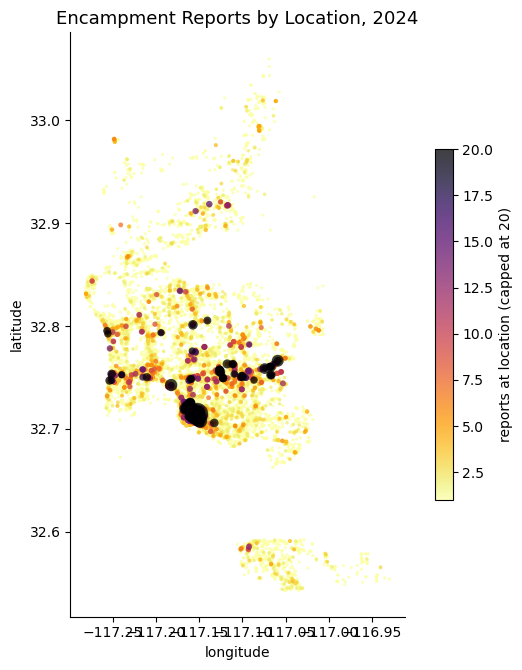

most reports at a single location: 211


In [13]:
counts = camp_data.groupby("location_id").size().rename("n").reset_index()
geo = unique_coords.merge(counts, on="location_id").sort_values("n")

fig, ax = plt.subplots(figsize=(6.4, 6.8))
sc = ax.scatter(geo["longitude"], geo["latitude"], c=geo["n"],
                s=4 + geo["n"] * 1.2, cmap="inferno_r", alpha=0.75,
                linewidths=0, vmin=1, vmax=20)
ax.set_title("Encampment Reports by Location, 2024", fontsize=13)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_aspect(1 / 0.84)  # rough correction for latitude convergence
cb = fig.colorbar(sc, ax=ax, shrink=0.6)
cb.set_label("reports at location (capped at 20)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("most reports at a single location:", geo["n"].max())

The city's shape emerges from the reports alone — we never loaded a basemap. The dense dark mass is Downtown; you can pick out corridors running east along the I-8 and El Cajon Blvd.

One location drew **211 reports in a single year** — a report every 1.7 days, all year, from one ~11 m square. That is either a genuinely persistent encampment or one extremely persistent caller. Worth knowing which before you build a story around it.

## Building the `.cas` file

SaTScan's case file wants one row per (location, date) with a count. We aggregate.

In [14]:
aggregated_df = camp_data.groupby(["date", "location_id"]).size().reset_index(name="cases")
aggregated_df = aggregated_df.sort_values(["date", "location_id"])
aggregated_df["case_id"] = range(1, len(aggregated_df) + 1)

cas_df = aggregated_df[["case_id", "date", "cases", "location_id"]].copy()
cas_df["date"] = cas_df["date"].dt.strftime("%Y/%m/%d")

print(cas_df.shape)
print("total cases:", cas_df["cases"].sum())
print("rows with more than one case:", (cas_df["cases"] > 1).sum())
cas_df.head()

(55784, 4)
total cases: 59042
rows with more than one case: 2636


,case_id,date,cases,location_id
0,1,2024/01/01,1,974
1,2,2024/01/01,1,2086
2,3,2024/01/01,1,2261
3,4,2024/01/01,1,2390
4,5,2024/01/01,1,2392


55,784 rows carrying 59,042 cases. Only 2,636 rows have a count above 1 — meaning same-day repeat reports at the same spot are the exception, not the rule.

This deserves one more moment of thought, because there's a judgment call hiding in that `groupby`. If three neighbors each call about the same tent on the same afternoon, we just recorded **3 cases**, not 1. Is that right?

There's no universal answer. If you're measuring *community concern*, three calls genuinely are three signals. If you're trying to count *encampments*, you've just triple-counted one tent and inflated a cluster. It depends entirely on what your research question is — so decide deliberately, and write down which you chose. To collapse them instead, drop duplicates on `["date", "location_id"]` before aggregating.

In [15]:
import os

OUT_DIR = "satscan_usable"
os.makedirs(OUT_DIR, exist_ok=True)

cas_path = os.path.join(OUT_DIR, "2024_camps.cas")
cas_df.to_csv(cas_path, index=False, header=True)
print("wrote", cas_path)

wrote satscan_usable/2024_camps.cas


## Building the `.geo` file

The geography file is the lookup table: one row per location ID, with its coordinates. Every location referenced in the `.cas` file must appear here, or SaTScan will refuse the run.

In [16]:
geo_df = (
    camp_data[["location_id", "latitude", "longitude"]]
    .drop_duplicates(subset=["location_id"])
    .sort_values("location_id")
)

if not ((geo_df["latitude"].between(-90, 90)) & (geo_df["longitude"].between(-180, 180))).all():
    raise ValueError("Invalid coordinates found in the data.")

geo_path = os.path.join(OUT_DIR, "2024_camps.geo")
geo_df.to_csv(geo_path, index=False, header=True)

print(geo_df.shape)
geo_df.head()

(31095, 3)


,location_id,latitude,longitude
55899,1,32.5434,-117.0340
5186,2,32.5436,-117.0512
30357,3,32.5436,-117.0510
15248,4,32.5436,-117.0502
6628,5,32.5436,-117.0499


## Validating before we hand off

SaTScan's error messages are terse and its silent failures are worse. It is much cheaper to assert our invariants here than to debug a suspicious cluster three hours from now.

Four things must hold: coordinates map one-to-one with location IDs, no ID is duplicated, every location in the case file exists in the geography file, and the case counts survived aggregation intact.

In [17]:
# 1:1 mapping between location_id and coordinate pair
assert not geo_df.duplicated(subset=["latitude", "longitude"]).any(), "duplicate coordinate pairs"
assert not geo_df.duplicated(subset=["location_id"]).any(), "duplicate location_ids"

# Referential integrity: every location in .cas must exist in .geo
assert set(cas_df["location_id"]).issubset(set(geo_df["location_id"])), "cas references unknown locations"

# Conservation: no cases invented or lost during aggregation
assert cas_df["cases"].sum() == len(camp_data), "case count does not match record count"

check = camp_data.groupby(["date", "location_id"]).size().reset_index(name="expected")
check["date"] = check["date"].dt.strftime("%Y/%m/%d")
merged = check.merge(cas_df, on=["date", "location_id"], how="inner")
assert len(merged) == len(cas_df) and (merged["expected"] == merged["cases"]).all(), "count mismatch"

print("All checks passed.")
print(f"  {len(geo_df):,} locations")
print(f"  {len(cas_df):,} case rows")
print(f"  {cas_df['cases'].sum():,} total cases")

All checks passed.
  31,095 locations
  55,784 case rows
  59,042 total cases


In [18]:
from datetime import datetime

min_date, max_date = cas_df["date"].min(), cas_df["date"].max()
start = datetime.strptime(min_date, "%Y/%m/%d")
end = datetime.strptime(max_date, "%Y/%m/%d")

print(f"Study Period Start: {min_date}")
print(f"Study Period End:   {max_date}")
print(f"Total days in study period: {(end - start).days + 1}")

Study Period Start: 2024/01/01
Study Period End:   2024/12/31
Total days in study period: 366


366 days — 2024 was a leap year. Write these dates down; SaTScan asks for them explicitly and will happily run with the wrong ones.

## Running SaTScan

Download SaTScan free from [satscan.org](https://www.satscan.org/). Create a new session and point it at the two files we just wrote.

**Input tab**
- Case File: `satscan_usable/2024_camps.cas`
- Coordinates File: `satscan_usable/2024_camps.geo`
- Coordinates: **Latitude/Longitude**
- Time Precision: **Day**
- Study Period: **2024/01/01** to **2024/12/31**

**Analysis tab**
- Type of Analysis: **Retrospective Space-Time**
- Probability Model: **Space-Time Permutation**
- Scan For Areas With: **High Rates**

The Space-Time Permutation model is the right choice here, and the reason is worth understanding rather than just copying. Most SaTScan models need a **population at risk** — to say a rate is high, you need to know high *relative to how many people could have been affected*. We don't have that. We have no idea how many people were in a position to file a 311 report at a given block on a given day.

Space-Time Permutation sidesteps this. It uses the data as its own control, asking: given how many reports this location produced all year, and given how many reports the whole city produced during this time window, is the number in *this place during this window* surprising? No denominator required. This is precisely why it was developed for disease surveillance, where the at-risk population is often equally unknowable.

Under **Output**, pick a filename and enable the Google Earth / KML output to see clusters on a map.

The default maximum spatial cluster size is 50% of the population at risk, which is almost always too permissive and tends to return one enormous blob. Try 10% under the Spatial Window tab. Under Temporal Window, the maximum defaults to 50% of the study period — for a year of data, consider 30 days if you're hunting for acute flare-ups rather than season-long shifts.

## Reading the output honestly

SaTScan will hand you a ranked list of clusters, each with a center, a radius, a date range, an observed-vs-expected ratio, and a p-value. The temptation is to read the top cluster as a discovery. Before you do, three things deserve your skepticism.

**The p-values are not what you're used to.** They come from Monte Carlo simulation — SaTScan shuffles your data hundreds of times and asks how often chance produces something this extreme. That's a real and well-founded procedure, but it tests a narrow null hypothesis: *no space-time interaction, given the observed margins*. It does not test "nothing interesting is happening," and it cannot rescue you from a biased sample.

**Clusters of reports are not clusters of encampments.** Say it out loud once more. A neighborhood that organizes a reporting campaign will light up. A neighborhood where people have concluded that calling 311 accomplishes nothing will go dark — and it will go dark *regardless of how many encampments are there*. This method cannot see what nobody reported. That gap is not random; it correlates with language, immigration status, housing tenure, and trust in city government.

**Some clusters are administrative artifacts.** If the city ran an enforcement sweep in a district in March, you'll find a March cluster in that district. It's real — but it's a cluster of *city activity*, not of the underlying phenomenon. Before interpreting any cluster, check the news and the city's own outreach calendar for that window.

The right posture is the one you'd take with any exploratory analysis: these results generate hypotheses, they don't confirm them. A cluster is an invitation to go find out what happened there, not a conclusion about what happened there.

And a note on stakes. This dataset is about unhoused people — some of the most surveilled and least powerful residents of the city. A map of "hot spots" can inform outreach and services, or it can be used to direct enforcement at people whose actual problem is that they have nowhere to go. The math is identical either way; the choice is yours and it is not a technical one.

## Try it out for yourself!

Take a look at the data for yourself and see what hypotheses you can generate. Some questions to explore:

- **Does the cluster survive?** Re-run at `COORD_PRECISION = 3` and again at `5`. Which clusters persist across all three, and which vanish? Only the persistent ones are worth writing up.
- **Reports or encampments?** Collapse same-day duplicate reports at a location, re-run, and compare. If your top cluster depends on counting three calls about one tent as three cases, that's a finding about your pipeline, not about San Diego.
- **Does the season matter?** Split the year into quarters and run each separately. Do clusters move, or do the same blocks recur?
- **Bring a denominator.** The `status` column distinguishes `Closed` from `Referred`. Do clusters of *referred* cases differ from clusters of all cases? What would it mean if they did?
- **Add context.** The portal hosts other datasets, and the Census publishes tract-level demographics. If you can build a plausible population-at-risk layer, the Poisson model becomes available and asks a different, sharper question.
- **Go multi-year.** Pull 2023 and 2024, run a Prospective Space-Time analysis, and ask which clusters are still active at the end of the study period rather than which ones ever existed.

The dataset is public, SaTScan is free, and this notebook runs top to bottom. The hard part was never the code.